✅ Semua file berhasil dimuat.
Lokasi dataset: /Users/azzizabdulghofur/Documents/Telkom University/Kompetisi/Lomba/ML-KOMPETISI-INTELLECTRA-2025-IPB/dataset

ANALISIS: Data Anggota (member_data.csv)

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46401 entries, 0 to 46400
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   MemberID        46401 non-null  object
 1   JoinDate        46401 non-null  object
 2   DateOfBirth     1477 non-null   object
 3   City            46401 non-null  object
 4   NoOfChild       46401 non-null  int64 
 5   EldestKidDOB    46401 non-null  object
 6   YoungestKidDOB  46401 non-null  object
dtypes: int64(1), object(6)
memory usage: 2.5+ MB

Statistik Deskriptif:
                                MemberID    JoinDate DateOfBirth    City  \
count                              46401       46401        1477   46401   
unique                             46401        1622         

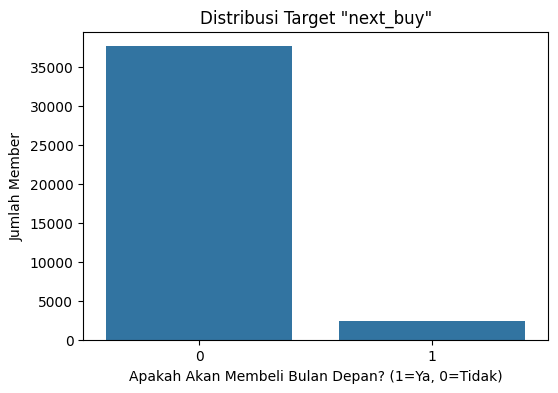


ANALISIS: Data Produk (product_data.csv)

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   productID        27 non-null     int64 
 1   ProductName      27 non-null     object
 2   ProductCategory  27 non-null     object
 3   ProductLevel     27 non-null     object
dtypes: int64(1), object(3)
memory usage: 996.0+ bytes

Jumlah Nilai Hilang:
productID          0
ProductName        0
ProductCategory    0
ProductLevel       0
dtype: int64

Contoh Data:
   productID        ProductName ProductCategory ProductLevel
0          1                A 3               A     Original
1          2                B 4               B     Original
2          3                A G               A      Premium
3          4                B G               B      Premium
4          9  A G FOR HOME KIOS               A      Premium

ANALISIS: Data Prog

In [21]:
# ==============================================================================
# TAHAP 1: IMPORT LIBRARY DAN MEMUAT DATA
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Mengatur path ke folder dataset dari folder notebooks
# Tanda '..' berarti 'naik satu level direktori'
base_path = '../dataset/'

# Memuat semua dataset yang relevan
try:
    member_df = pd.read_csv(os.path.join(base_path, 'member_data.csv'))
    train_trans_df = pd.read_csv(os.path.join(base_path, 'train_transaction_data.csv'))
    train_label_df = pd.read_csv(os.path.join(base_path, 'train_label_data.csv'))
    product_df = pd.read_csv(os.path.join(base_path, 'product_data.csv'))
    prodgram_df = pd.read_csv(os.path.join(base_path, 'prodgram_data.csv'))
    
    print("✅ Semua file berhasil dimuat.")
    print("Lokasi dataset:", os.path.abspath(base_path))
except FileNotFoundError as e:
    print(f"❌ Gagal memuat file: {e}")
    print("Pastikan file CSV Anda berada di dalam folder 'dataset' dan notebook ini berada di dalam folder 'notebooks'.")

# ==============================================================================
# TAHAP 2: ANALISIS SETIAP TABEL SECARA INDIVIDUAL
# ==============================================================================

print("\n" + "="*50)
print("ANALISIS: Data Anggota (member_data.csv)")
print("="*50)
print("\nInfo Data:")
member_df.info()
print("\nStatistik Deskriptif:")
print(member_df.describe(include='all'))
print("\nJumlah Nilai Hilang:")
print(member_df.isnull().sum())
print("\nContoh Data:")
print(member_df.head())


print("\n" + "="*50)
print("ANALISIS: Data Transaksi Latih (train_transaction_data.csv)")
print("="*50)
print("\nInfo Data:")
train_trans_df.info()
print("\nStatistik Deskriptif:")
print(train_trans_df.describe(include='all'))
print("\nJumlah Nilai Hilang:")
print(train_trans_df.isnull().sum())
print("\nContoh Data:")
print(train_trans_df.head())


print("\n" + "="*50)
print("ANALISIS: Data Label Latih (train_label_data.csv)")
print("="*50)
print("\nInfo Data:")
train_label_df.info()
print("\nJumlah Nilai Hilang:")
print(train_label_df.isnull().sum())
print("\nDistribusi Target (next_buy):")
print(train_label_df['next_buy'].value_counts(normalize=True))
print("\nContoh Data:")
print(train_label_df.head())

# Visualisasi distribusi target
plt.figure(figsize=(6, 4))
sns.countplot(x='next_buy', data=train_label_df)
plt.title('Distribusi Target "next_buy"')
plt.xlabel('Apakah Akan Membeli Bulan Depan? (1=Ya, 0=Tidak)')
plt.ylabel('Jumlah Member')
plt.show()


print("\n" + "="*50)
print("ANALISIS: Data Produk (product_data.csv)")
print("="*50)
print("\nInfo Data:")
product_df.info()
print("\nJumlah Nilai Hilang:")
print(product_df.isnull().sum())
print("\nContoh Data:")
print(product_df.head())


print("\n" + "="*50)
print("ANALISIS: Data Program Produk (prodgram_data.csv)")
print("="*50)
print("\nInfo Data:")
prodgram_df.info()
print("\nJumlah Nilai Hilang:")
print(prodgram_df.isnull().sum())
print("\nContoh Data:")
print(prodgram_df.head())


# ==============================================================================
# TAHAP 3: PENGGABUNGAN DATA AWAL (FIRST MERGE)
# ==============================================================================
print("\n" + "="*50)
print("PENGGABUNGAN DATA AWAL")
print("="*50)

# Menggabungkan data transaksi latih dengan labelnya
train_merged_df = pd.merge(train_trans_df, train_label_df, on='MemberID', how='left')

print("Info data setelah digabung dengan label:")
train_merged_df.info()

print("\nJumlah nilai hilang di kolom 'next_buy' setelah merge:")
print(f"{train_merged_df['next_buy'].isnull().sum()} (Seharusnya 0 jika semua MemberID di data transaksi ada di data label)")

print("\nContoh data gabungan:")
print(train_merged_df.head())

In [22]:
# ==============================================================================
# TAHAP 4: PEMBERSIHAN DAN PERSIAPAN DATA (KODE YANG DIPERBAIKI)
# ==============================================================================
print("Memulai proses pembersihan data...")

# Salin dataframe agar data asli tidak berubah
member_clean = member_df.copy()
train_trans_clean = train_trans_df.copy()
prodgram_clean = prodgram_df.copy()

# --- 1. Mengubah Tipe Data Kolom Tanggal ---
print("\n1. Mengubah tipe data kolom tanggal menjadi datetime...")
date_cols_member = ['JoinDate', 'EldestKidDOB', 'YoungestKidDOB']
# Kita tidak memasukkan 'DateOfBirth' karena akan dihapus
for col in date_cols_member:
    member_clean[col] = pd.to_datetime(member_clean[col], errors='coerce')

train_trans_clean['TransactionDatetime'] = pd.to_datetime(train_trans_clean['TransactionDatetime'])

print("Tipe data member_clean setelah diubah:")
print(member_clean.dtypes)
print("\nTipe data train_trans_clean setelah diubah:")
print(train_trans_clean.dtypes)


# --- 2. Menangani Nilai Hilang (Missing Values) ---
print("\n2. Menangani nilai hilang...")

# 2a. DateOfBirth pada member_data kita drop karena >95% hilang
member_clean = member_clean.drop(columns=['DateOfBirth'])
print("- Kolom 'DateOfBirth' telah dihapus.")

# 2b. PricePerUnit pada data transaksi
# Strategi: Isi dengan harga referensi dari prodgram_data
train_trans_clean = pd.merge(
    train_trans_clean,
    prodgram_clean[['prodgramID', 'Price']],
    left_on='FK_PROD_GRAM_ID',
    right_on='prodgramID',
    how='left'
)

# --- INILAH BAGIAN YANG DIPERBAIKI ---
# Mengisi PricePerUnit yang kosong dengan Price dari prodgram
train_trans_clean['PricePerUnit'] = train_trans_clean['PricePerUnit'].fillna(train_trans_clean['Price'])

# Hapus kolom bantu yang sudah tidak diperlukan
train_trans_clean = train_trans_clean.drop(columns=['prodgramID', 'Price'])
print(f"- Nilai hilang di 'PricePerUnit' setelah diisi dari harga referensi: {train_trans_clean['PricePerUnit'].isnull().sum()}")

# Jika masih ada yg kosong, isi dengan median
if train_trans_clean['PricePerUnit'].isnull().sum() > 0:
    median_price = train_trans_clean['PricePerUnit'].median()
    # --- INILAH BAGIAN KEDUA YANG DIPERBAIKI ---
    train_trans_clean['PricePerUnit'] = train_trans_clean['PricePerUnit'].fillna(median_price)
    print(f"- Mengisi sisa nilai hilang 'PricePerUnit' dengan median ({median_price}).")


# --- 3. Menggabungkan Semua Data Menjadi Satu DataFrame Final ---
print("\n3. Menggabungkan semua tabel menjadi satu DataFrame...")

# Gabungkan data transaksi yang sudah bersih dengan data member
df_train_full = pd.merge(train_trans_clean, member_clean, on='MemberID', how='left')

# Gabungkan dengan data produk
product_df_renamed = product_df.rename(columns={'productID': 'FK_PRODUCT_ID'})
df_train_full = pd.merge(df_train_full, product_df_renamed, on='FK_PRODUCT_ID', how='left')

# Gabungkan dengan data prodgram (untuk info gramasi & poin)
prodgram_df_renamed = prodgram_df.rename(columns={'prodgramID': 'FK_PROD_GRAM_ID'})
df_train_full = pd.merge(df_train_full, prodgram_df_renamed, on='FK_PROD_GRAM_ID', how='left')


print("\n--- DATA BERSIH DAN LENGKAP SIAP UNTUK FEATURE ENGINEERING ---")
print("Info Data Gabungan Final:")
df_train_full.info()

print("\nMemeriksa kembali nilai hilang pada data gabungan:")
# Tampilkan hanya kolom yang masih memiliki nilai hilang
missing_final = df_train_full.isnull().sum()
print(missing_final[missing_final > 0])

Memulai proses pembersihan data...

1. Mengubah tipe data kolom tanggal menjadi datetime...
Tipe data member_clean setelah diubah:
MemberID                  object
JoinDate          datetime64[ns]
DateOfBirth               object
City                      object
NoOfChild                  int64
EldestKidDOB      datetime64[ns]
YoungestKidDOB    datetime64[ns]
dtype: object

Tipe data train_trans_clean setelah diubah:
TransactionID                       object
MemberID                            object
Source                              object
FK_PRODUCT_ID                        int64
FK_PROD_GRAM_ID                      int64
Qty                                  int64
PricePerUnit                       float64
TransactionDatetime    datetime64[ns, UTC]
dtype: object

2. Menangani nilai hilang...
- Kolom 'DateOfBirth' telah dihapus.
- Nilai hilang di 'PricePerUnit' setelah diisi dari harga referensi: 0

3. Menggabungkan semua tabel menjadi satu DataFrame...

--- DATA BERSIH DAN LENGKA

In [23]:
# ==============================================================================
# TAHAP 5: FEATURE ENGINEERING (STRATEGI BARU)
# ==============================================================================
print("Memulai proses rekayasa fitur dengan strategi baru...")

# --- 1. Fitur-fitur lama yang masih relevan ---
df_train_full['TotalPrice'] = df_train_full['Qty'] * df_train_full['PricePerUnit']
snapshot_date = df_train_full['TransactionDatetime'].max() + pd.Timedelta(days=1)

# --- 2. FITUR BARU #1: Jarak Antar Pembelian (Inter-purchase Time) ---
# Fitur ini mengukur keteraturan pelanggan. Sangat kuat untuk prediksi.
df_train_full = df_train_full.sort_values(by=['MemberID', 'TransactionDatetime'])
# Hitung selisih waktu antar transaksi untuk setiap member
df_train_full['interpurchase_time'] = df_train_full.groupby('MemberID')['TransactionDatetime'].diff().dt.days

# Agregasi untuk mendapatkan rata-rata dan standar deviasi jarak antar pembelian
interpurchase_features = df_train_full.groupby('MemberID')['interpurchase_time'].agg(['mean', 'std']).reset_index()
interpurchase_features = interpurchase_features.rename(columns={'mean': 'avg_interpurchase_time', 'std': 'std_interpurchase_time'})
# Isi NaN dengan 0 (untuk member yang hanya belanja sekali)
interpurchase_features = interpurchase_features.fillna(0)
print("- Fitur 'jarak antar pembelian' telah dibuat.")

# --- 3. Agregasi Utama ---
features_df = df_train_full.groupby('MemberID').agg(
    recency=('TransactionDatetime', lambda date: (snapshot_date - date.max()).days),
    frequency_trans=('TransactionID', 'count'),
    monetary_total=('TotalPrice', 'sum'),
    monetary_mean=('TotalPrice', 'mean'),
    product_unique_count=('FK_PRODUCT_ID', 'nunique'),
).reset_index()

# --- 4. Gabungkan dengan fitur baru ---
features_df = pd.merge(features_df, interpurchase_features, on='MemberID', how='left')

# --- 5. Gabungkan dengan fitur statis member ---
member_static_features = member_clean.drop_duplicates(subset=['MemberID']).copy()
snapshot_date_naive = snapshot_date.tz_localize(None)
member_static_features['tenure_days'] = (snapshot_date_naive - member_static_features['JoinDate']).dt.days
features_df = pd.merge(features_df, member_static_features[['MemberID', 'NoOfChild', 'tenure_days']], on='MemberID', how='left')

# --- 6. FITUR BARU #2 & #3: Fitur Rasio dan Relatif ---
# Fitur-fitur ini tidak sensitif terhadap waktu absolut
features_df['frequency_per_tenure'] = features_df['frequency_trans'] / (features_df['tenure_days'] + 1)
features_df['monetary_per_tenure'] = features_df['monetary_total'] / (features_df['tenure_days'] + 1)
print("- Fitur rasio dan relatif telah dibuat.")

# --- 7. Finalisasi ---
# Gabungkan dengan label target
final_train_df = pd.merge(features_df, train_label_df, on='MemberID', how='left')
# Isi nilai null yang mungkin muncul
final_train_df.fillna(0, inplace=True)

print("\n--- PROSES REKAYASA FITUR SELESAI ---")
print("Dimensi data latih final:", final_train_df.shape)
print("\nContoh Data Latih Final:")
print(final_train_df.head())

Memulai proses rekayasa fitur dengan strategi baru...
- Fitur 'jarak antar pembelian' telah dibuat.
- Fitur rasio dan relatif telah dibuat.

--- PROSES REKAYASA FITUR SELESAI ---
Dimensi data latih final: (40020, 13)

Contoh Data Latih Final:
                           MemberID  recency  frequency_trans  monetary_total  \
0  00010c8a563eb5555709c8ae3120ba2e      161                1         83000.0   
1  000184877b42ade87143636847f305a8      254                1        270000.0   
2  0003a82569e3202cfecc55d987da0f70        3               11       4324000.0   
3  00045f29692019c0fa274e5330c5dbaf      116                2        272000.0   
4  0004aec4786c2b071360a0967b39f4f5      132               20       3416500.0   

   monetary_mean  product_unique_count  avg_interpurchase_time  \
0   83000.000000                     1                0.000000   
1  270000.000000                     1                0.000000   
2  393090.909091                     1               13.700000   
3  136

Memulai proses persiapan dan pelatihan model...

Fitur (X) dan Target (y) sudah dipisahkan.
Dimensi Fitur (X): (40020, 11)

VALIDASI BERBASIS WAKTU: Data latih: 35856 baris, Data validasi: 4164 baris

Melatih model LightGBM dengan parameter regularisasi...
Nilai scale_pos_weight untuk kelas positif: 46.62

Mengevaluasi performa model pada data validasi...

🏆 Balanced Accuracy Score (strategi baru): 0.5011

Laporan Klasifikasi:
                precision    recall  f1-score   support

Tidak Beli (0)       0.60      0.99      0.74      2479
      Beli (1)       0.45      0.01      0.03      1685

      accuracy                           0.59      4164
     macro avg       0.52      0.50      0.38      4164
  weighted avg       0.54      0.59      0.45      4164


Confusion Matrix:


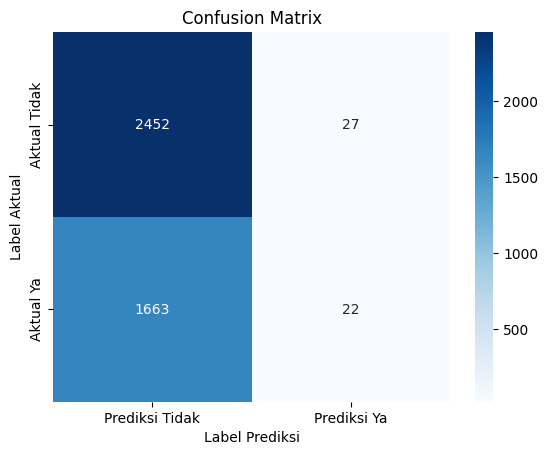

In [24]:
# ==============================================================================
# TAHAP 6: PELATIHAN DAN EVALUASI MODEL (PERBAIKAN FINAL)
# ==============================================================================
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Memulai proses persiapan dan pelatihan model...")

# --- 1. Persiapan Data untuk Model ---
X = final_train_df.drop(columns=['MemberID', 'next_buy'])
y = final_train_df['next_buy']

# ### INILAH BAGIAN YANG DIPERBAIKI ###
# Baris di bawah ini dihapus karena 'City_simplified' sudah tidak ada lagi
# X['City_simplified'] = X['City_simplified'].astype('category') 

print("\nFitur (X) dan Target (y) sudah dipisahkan.")
print("Dimensi Fitur (X):", X.shape)

# --- 2. Validasi Berbasis Waktu ---
last_trans_df = df_train_full.groupby('MemberID')['TransactionDatetime'].max().reset_index()
last_trans_df = last_trans_df.rename(columns={'TransactionDatetime':'LastTransaction'})
split_df = pd.merge(final_train_df, last_trans_df, on='MemberID', how='left')
split_date = split_df['LastTransaction'].max() - pd.DateOffset(months=1)
train_indices = split_df[split_df['LastTransaction'] < split_date].index
val_indices = split_df[split_df['LastTransaction'] >= split_date].index

X_train = X.iloc[train_indices]
y_train = y.iloc[train_indices]
X_val = X.iloc[val_indices]
y_val = y.iloc[val_indices]

# Hapus kolom LastTransaction dari data validasi jika masih ada
if 'LastTransaction' in X_val.columns:
    X_val = X_val.drop(columns=['LastTransaction'])

print(f"\nVALIDASI BERBASIS WAKTU: Data latih: {len(X_train)} baris, Data validasi: {len(X_val)} baris")

# --- 3. Pelatihan Model LightGBM ---
print("\nMelatih model LightGBM dengan parameter regularisasi...")
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Nilai scale_pos_weight untuk kelas positif: {scale_pos_weight:.2f}")

lgbm = lgb.LGBMClassifier(
    objective='binary',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=20,
    max_depth=5,
    reg_alpha=0.1,
    reg_lambda=0.1,
    colsample_bytree=0.8,
    n_jobs=-1
)

lgbm.fit(X_train, y_train,
         eval_set=[(X_val, y_val)],
         eval_metric='balanced_accuracy',
         callbacks=[lgb.early_stopping(10, verbose=False)])

# --- 4. Evaluasi Model pada Data Validasi ---
print("\nMengevaluasi performa model pada data validasi...")

y_pred = lgbm.predict(X_val)
balanced_acc = balanced_accuracy_score(y_val, y_pred)
print(f"\n================================================")
print(f"🏆 Balanced Accuracy Score (strategi baru): {balanced_acc:.4f}")
print(f"================================================")

print("\nLaporan Klasifikasi:")
print(classification_report(y_val, y_pred, target_names=['Tidak Beli (0)', 'Beli (1)']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Prediksi Tidak', 'Prediksi Ya'], yticklabels=['Aktual Tidak', 'Aktual Ya'])
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.title('Confusion Matrix')
plt.show()

In [25]:
# ==============================================================================
# TAHAP 7: OPTIMASI HIPERPARAMETER DENGAN OPTUNA (PERBAIKAN FINAL)
# ==============================================================================
try:
    import optuna
except ImportError:
    print("Menginstal optuna...")
    !pip install optuna
    import optuna

# Fungsi 'objective' yang sudah diperbaiki
def objective(trial):
    # 1. Tentukan rentang parameter HANYA UNTUK PEMBUATAN MODEL
    params = {
        'objective': 'binary',
        'random_state': 42,
        'n_jobs': -1,
        'scale_pos_weight': scale_pos_weight, # Gunakan dari tahap sebelumnya
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08),
        'num_leaves': trial.suggest_int('num_leaves', 15, 40),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'verbose': -1 # Untuk menekan output berlebih dari LightGBM
    }
    
    # 2. Inisialisasi model
    model = lgb.LGBMClassifier(**params)
    
    # 3. Latih model dengan SEMUA parameter evaluasi didefinisikan secara eksplisit di sini
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              eval_metric='balanced_accuracy', # <-- Didefinisikan secara eksplisit di sini
              callbacks=[lgb.early_stopping(15, verbose=False)])
    
    # 4. Evaluasi dan kembalikan skor
    preds = model.predict(X_val)
    score = balanced_accuracy_score(y_val, preds)
    
    return score

# Buat dan jalankan studi Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Tampilkan hasil terbaik
print("\n--- OPTIMASI SELESAI ---")
print("Skor Balanced Accuracy terbaik di validasi:", study.best_value)
print("Kombinasi parameter terbaik:", study.best_params)

# Simpan parameter terbaik untuk Tahap 8
best_params = study.best_params

[I 2025-07-08 00:34:02,918] A new study created in memory with name: no-name-fe58bbe6-e7e3-43ae-be07-a5451e29386c
Best trial: 0. Best value: 0.502163:   0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-07-08 00:34:02,962] Trial 0 finished with value: 0.5021627367213974 and parameters: {'n_estimators': 828, 'learning_rate': 0.06770759937655142, 'num_leaves': 24, 'max_depth': 4, 'reg_alpha': 0.07185331270075383, 'reg_lambda': 0.837159786906077, 'colsample_bytree': 0.8056549774604042}. Best is trial 0 with value: 0.5021627367213974.


Best trial: 3. Best value: 0.510265:   8%|▊         | 4/50 [00:00<00:02, 17.05it/s]

[I 2025-07-08 00:34:03,051] Trial 1 finished with value: 0.49959661153691004 and parameters: {'n_estimators': 706, 'learning_rate': 0.04487326177775375, 'num_leaves': 29, 'max_depth': 8, 'reg_alpha': 0.03422470080118346, 'reg_lambda': 0.6875798594580456, 'colsample_bytree': 0.8497123641861519}. Best is trial 0 with value: 0.5021627367213974.
[I 2025-07-08 00:34:03,119] Trial 2 finished with value: 0.5 and parameters: {'n_estimators': 207, 'learning_rate': 0.02537934311479975, 'num_leaves': 32, 'max_depth': 4, 'reg_alpha': 0.8102811648163145, 'reg_lambda': 0.662728338942158, 'colsample_bytree': 0.8598807007547232}. Best is trial 0 with value: 0.5021627367213974.
[I 2025-07-08 00:34:03,158] Trial 3 finished with value: 0.5102645007379495 and parameters: {'n_estimators': 977, 'learning_rate': 0.07868144759891717, 'num_leaves': 37, 'max_depth': 4, 'reg_alpha': 0.17236067095844163, 'reg_lambda': 0.4493707312304624, 'colsample_bytree': 0.917316914246746}. Best is trial 3 with value: 0.510264

Best trial: 3. Best value: 0.510265:   8%|▊         | 4/50 [00:00<00:02, 17.05it/s]

...

[I 2025-07-08 00:34:06,795] Trial 43 finished with value: 0.6936840379065455 and parameters: {'n_estimators': 414, 'learning_rate': 0.07550925859187793, 'num_leaves': 32, 'max_depth': 8, 'reg_alpha': 0.17570183116331178, 'reg_lambda': 0.32049444988470815, 'colsample_bytree': 0.7556394340800231}. Best is trial 43 with value: 0.6936840379065455.
[I 2025-07-08 00:34:06,890] Trial 44 finished with value: 0.5011310437945807 and parameters: {'n_estimators': 414, 'learning_rate': 0.07580165076846453, 'num_leaves': 34, 'max_depth': 7, 'reg_alpha': 0.1780923800481557, 'reg_lambda': 0.32488773945901656, 'colsample_bytree': 0.7452409710040162}. Best is trial 43 with value: 0.6936840379065455.


Best trial: 43. Best value: 0.693684:  96%|█████████▌| 48/50 [00:04<00:00, 10.74it/s]

[I 2025-07-08 00:34:07,017] Trial 45 finished with value: 0.5004635974829518 and parameters: {'n_estimators': 510, 'learning_rate': 0.031425052540820245, 'num_leaves': 32, 'max_depth': 7, 'reg_alpha': 0.2700226710082911, 'reg_lambda': 0.266769615732176, 'colsample_bytree': 0.7211432167841539}. Best is trial 43 with value: 0.6936840379065455.
[I 2025-07-08 00:34:07,078] Trial 46 finished with value: 0.49939491730536506 and parameters: {'n_estimators': 563, 'learning_rate': 0.0730530061656672, 'num_leaves': 35, 'max_depth': 5, 'reg_alpha': 0.3338838728966581, 'reg_lambda': 0.17539325868821398, 'colsample_bytree': 0.7004135040783097}. Best is trial 43 with value: 0.6936840379065455.
[I 2025-07-08 00:34:07,175] Trial 47 finished with value: 0.4982681827050488 and parameters: {'n_estimators': 405, 'learning_rate': 0.0665131723189638, 'num_leaves': 37, 'max_depth': 8, 'reg_alpha': 0.5219213935917422, 'reg_lambda': 0.33142512047442907, 'colsample_bytree': 0.741226895985677}. Best is trial 43 

Best trial: 43. Best value: 0.693684: 100%|██████████| 50/50 [00:04<00:00, 11.32it/s]

[I 2025-07-08 00:34:07,259] Trial 48 finished with value: 0.5 and parameters: {'n_estimators': 448, 'learning_rate': 0.07947480259245901, 'num_leaves': 34, 'max_depth': 8, 'reg_alpha': 0.6704608533625063, 'reg_lambda': 0.35582712113645026, 'colsample_bytree': 0.8769993717244672}. Best is trial 43 with value: 0.6936840379065455.
[I 2025-07-08 00:34:07,335] Trial 49 finished with value: 0.5 and parameters: {'n_estimators': 393, 'learning_rate': 0.07593654735901553, 'num_leaves': 28, 'max_depth': 7, 'reg_alpha': 0.4747683839293405, 'reg_lambda': 0.23732854241326556, 'colsample_bytree': 0.9093750965728222}. Best is trial 43 with value: 0.6936840379065455.

--- OPTIMASI SELESAI ---
Skor Balanced Accuracy terbaik di validasi: 0.6936840379065455
Kombinasi parameter terbaik: {'n_estimators': 414, 'learning_rate': 0.07550925859187793, 'num_leaves': 32, 'max_depth': 8, 'reg_alpha': 0.17570183116331178, 'reg_lambda': 0.32049444988470815, 'colsample_bytree': 0.7556394340800231}


In [26]:
# ==============================================================================
# TAHAP 8: FINAL MODEL TRAINING & SUBMISSION (SINKRONISASI FINAL)
# ==============================================================================
print("--- Memulai Proses Pembuatan Submission ---")

# --- 1. Final Model Training (menggunakan 100% data latih & parameter terbaik) ---
print("\n1. Melatih model final pada seluruh data latih...")

# Menggunakan final_train_df dari Tahap 5 yang baru (tanpa fitur City)
X_full_train = final_train_df.drop(columns=['MemberID', 'next_buy'])
y_full_train = final_train_df['next_buy']

# ### BAGIAN YANG DIPERBAIKI ###
# Baris yang mencoba mengakses 'City_simplified' dihapus karena fitur tersebut sudah tidak ada
# X_full_train['City_simplified'] = X_full_train['City_simplified'].astype('category')

# Gunakan parameter terbaik dari studi Optuna (jika sudah dijalankan)
try:
    best_params['objective'] = 'binary'
    best_params['scale_pos_weight'] = y_full_train.value_counts()[0] / y_full_train.value_counts()[1]
    best_params['random_state'] = 42
    best_params['n_jobs'] = -1
    print("Menggunakan parameter terbaik dari hasil optimasi Optuna...")
    final_lgbm = lgb.LGBMClassifier(**best_params)
except NameError:
    print("Variabel 'best_params' tidak ditemukan. Menggunakan parameter regularisasi default...")
    final_lgbm = lgb.LGBMClassifier(objective='binary', random_state=42, n_jobs=-1, n_estimators=500, learning_rate=0.05, num_leaves=20, max_depth=5, reg_alpha=0.1, reg_lambda=0.1, colsample_bytree=0.8)

# Latih model final (tanpa categorical_feature)
final_lgbm.fit(X_full_train, y_full_train)
print("Model final berhasil dilatih.")


# --- 2. Memuat dan Memproses Data Tes ---
print("\n2. Memuat dan memproses data tes dengan pipeline yang sama persis...")
test_trans_df = pd.read_csv('../dataset/test_transaction_data.csv')
sample_submission_df = pd.read_csv('../submission/sample_submission.csv')

# --- Menjalankan SEMUA langkah cleaning & feature engineering yang SAMA pada data tes ---
# 2a. Cleaning
test_trans_clean = test_trans_df.copy(); test_trans_clean['TransactionDatetime'] = pd.to_datetime(test_trans_clean['TransactionDatetime']); test_trans_clean = pd.merge(test_trans_clean, prodgram_clean[['prodgramID', 'Price']], left_on='FK_PROD_GRAM_ID', right_on='prodgramID', how='left'); test_trans_clean['PricePerUnit'] = test_trans_clean['PricePerUnit'].fillna(test_trans_clean['Price']); test_trans_clean = test_trans_clean.drop(columns=['prodgramID', 'Price']);
if test_trans_clean['PricePerUnit'].isnull().sum() > 0: median_price_train = X_full_train['PricePerUnit'].median(); test_trans_clean['PricePerUnit'] = test_trans_clean['PricePerUnit'].fillna(median_price_train);
df_test_full = pd.merge(test_trans_clean, member_clean, on='MemberID', how='left'); product_df_renamed = product_df.rename(columns={'productID': 'FK_PRODUCT_ID'}); df_test_full = pd.merge(df_test_full, product_df_renamed, on='FK_PRODUCT_ID', how='left');

# 2b. Feature Engineering (mengikuti TAHAP 5 yang baru)
df_test_full = df_test_full.sort_values(by=['MemberID', 'TransactionDatetime'])
df_test_full['interpurchase_time'] = df_test_full.groupby('MemberID')['TransactionDatetime'].diff().dt.days
interpurchase_features_test = df_test_full.groupby('MemberID')['interpurchase_time'].agg(['mean', 'std']).reset_index().rename(columns={'mean': 'avg_interpurchase_time', 'std': 'std_interpurchase_time'}).fillna(0)

df_test_full['TotalPrice'] = df_test_full['Qty'] * df_test_full['PricePerUnit']
test_features_df = df_test_full.groupby('MemberID').agg(recency=('TransactionDatetime', lambda date: (snapshot_date - date.max()).days), frequency_trans=('TransactionID', 'count'), monetary_total=('TotalPrice', 'sum'), monetary_mean=('TotalPrice', 'mean'), product_unique_count=('FK_PRODUCT_ID', 'nunique')).reset_index()
test_features_df = pd.merge(test_features_df, interpurchase_features_test, on='MemberID', how='left')

member_static_features_test = member_clean.drop_duplicates(subset=['MemberID']).copy(); snapshot_date_naive = snapshot_date.tz_localize(None); member_static_features_test['tenure_days'] = (snapshot_date_naive - member_static_features_test['JoinDate']).dt.days; 
test_features_df = pd.merge(test_features_df, member_static_features_test[['MemberID', 'NoOfChild', 'tenure_days']], on='MemberID', how='left')

test_features_df['frequency_per_tenure'] = test_features_df['frequency_trans'] / (test_features_df['tenure_days'] + 1)
test_features_df['monetary_per_tenure'] = test_features_df['monetary_total'] / (test_features_df['tenure_days'] + 1)

# Gabungkan dengan kerangka submission
final_test_df = pd.merge(sample_submission_df[['MemberID']], test_features_df, on='MemberID', how='left')
# Isi nilai null yang mungkin muncul (misal: member tes baru yang tidak ada di data transaksi)
final_test_df.fillna(0, inplace=True) 
print("Data tes berhasil diproses.")

# --- 3. Membuat Prediksi dan Menyimpan File ---
print("\n3. Membuat prediksi pada data tes...")
# Pastikan urutan kolom sama persis dengan data latih
X_test_final = final_test_df[X_full_train.columns]
test_predictions = final_lgbm.predict(X_test_final)

submission_df = pd.DataFrame({'MemberID': final_test_df['MemberID'], 'next_buy': test_predictions})
submission_df.to_csv('../submission/submissionV4.csv', index=False)

print("\n🎉 File 'submission_new_features.csv' telah berhasil dibuat di folder 'submissions'!")
print(submission_df.head())

--- Memulai Proses Pembuatan Submission ---

1. Melatih model final pada seluruh data latih...
Menggunakan parameter terbaik dari hasil optimasi Optuna...
Model final berhasil dilatih.

2. Memuat dan memproses data tes dengan pipeline yang sama persis...
Data tes berhasil diproses.

3. Membuat prediksi pada data tes...

🎉 File 'submission_new_features.csv' telah berhasil dibuat di folder 'submissions'!
                           MemberID  next_buy
0  c2a630e3d0dc77dac0f63424a9ae1438         0
1  3ecf7484c08418953e967a20de37051b         0
2  97bbd6c99a862f20657d9b2b1c77b2c8         0
3  3ce072ff9c6f2f4b7c95dbc08324a24d         0
4  ab0b0de2a1c85a40b5d58644aef745c0         0
